In [16]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

In [17]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [18]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1094,1338-CECEE,Male,0,Yes,Yes,41,Yes,Yes,DSL,No,...,Yes,No,Yes,No,One year,No,Bank transfer (automatic),68.50,2839.95,No
1912,0129-QMPDR,Male,0,Yes,Yes,44,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),20.50,865.05,No
6566,3795-CAWEX,Male,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.55,8152.3,No
1142,2460-NGXBJ,Male,1,Yes,Yes,11,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),75.20,775.3,No


In [19]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [20]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [21]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score



num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [24]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [25]:
def model_evaluate(n_stimators,depth):
    depths=[]
    accuracies=[]

    ## training model to max depth
    for depth in range(1,depth+1):
    
        ## Random Forest model
        rf_model = RandomForestClassifier(
            n_estimators=n_stimators,
            max_depth=depth,
            random_state=42
        )

        model = Pipeline([
        ('cleaning',FunctionTransformer(basic_cleaning)),
        ('preprocessing',preprocessor),
        ('model', rf_model)])


    
        ## train model
        model.fit(X_train, y_train)
    
        ## Predict
        y_pred = model.predict(X_test)
    
        ## Accuracy
        accuracy = accuracy_score(y_test, y_pred)
    
        depths.append(depth)
        accuracies.append(accuracy)
    
        print(f"Depth: {depth}, Accuracy: {accuracy}")

    # Visualization
    plt.figure(figsize=(8,5))
    
    plt.plot(depths, accuracies, marker='o')
    
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    
    plt.title("Random Forest Accuracy vs Max Depth")
    
    plt.grid(True)
    
    plt.show()
    
    # Best depth
    best_index = accuracies.index(max(accuracies))

    print("Best Depth:", depths[best_index])
    print("Best Accuracy:", accuracies[best_index])

Depth: 1, Accuracy: 0.7352732434350603
Depth: 2, Accuracy: 0.758694109297374
Depth: 3, Accuracy: 0.7856635911994322
Depth: 4, Accuracy: 0.7977288857345636
Depth: 5, Accuracy: 0.7984386089425124
Depth: 6, Accuracy: 0.7984386089425124
Depth: 7, Accuracy: 0.8034066713981547
Depth: 8, Accuracy: 0.8019872249822569
Depth: 9, Accuracy: 0.8062455642299503
Depth: 10, Accuracy: 0.8090844570617459


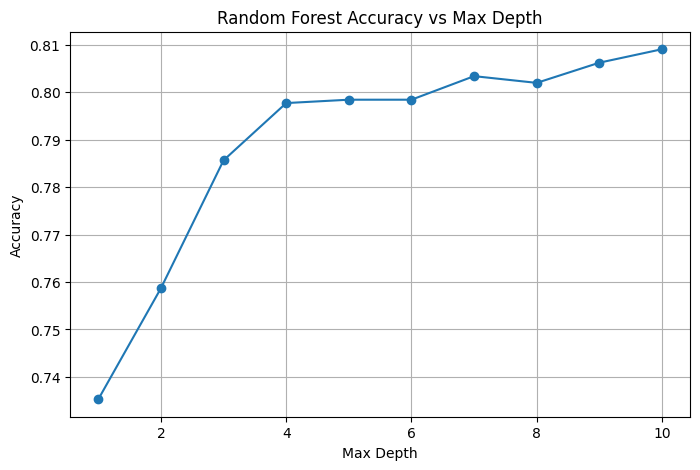

Best Depth: 10
Best Accuracy: 0.8090844570617459


In [34]:
E1=model_evaluate(100,10)

Depth: 1, Accuracy: 0.7352732434350603
Depth: 2, Accuracy: 0.7679205110007097
Depth: 3, Accuracy: 0.7856635911994322
Depth: 4, Accuracy: 0.7991483321504613
Depth: 5, Accuracy: 0.7984386089425124
Depth: 6, Accuracy: 0.7991483321504613
Depth: 7, Accuracy: 0.8062455642299503
Depth: 8, Accuracy: 0.8097941802696949
Depth: 9, Accuracy: 0.8041163946061036
Depth: 10, Accuracy: 0.8041163946061036
Depth: 11, Accuracy: 0.8034066713981547
Depth: 12, Accuracy: 0.7970191625266146
Depth: 13, Accuracy: 0.8019872249822569
Depth: 14, Accuracy: 0.7998580553584103
Depth: 15, Accuracy: 0.7927608232789212
Depth: 16, Accuracy: 0.794180269694819
Depth: 17, Accuracy: 0.7863733144073811
Depth: 18, Accuracy: 0.8005677785663591
Depth: 19, Accuracy: 0.7955997161107168
Depth: 20, Accuracy: 0.7877927608232789
Depth: 21, Accuracy: 0.7885024840312278
Depth: 22, Accuracy: 0.7984386089425124
Depth: 23, Accuracy: 0.7955997161107168
Depth: 24, Accuracy: 0.7963094393186657
Depth: 25, Accuracy: 0.7906316536550745


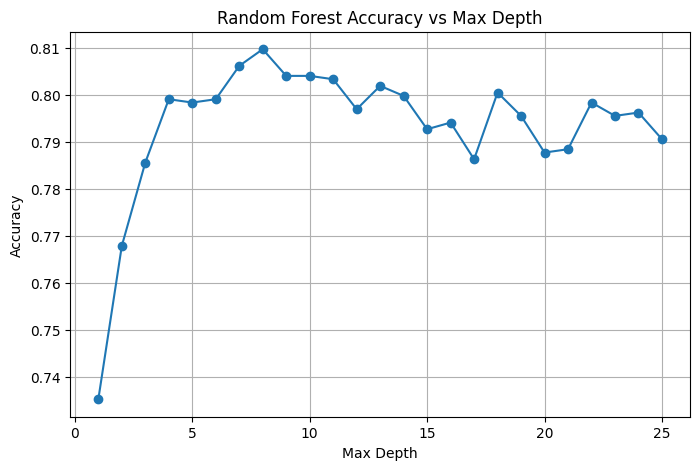

Best Depth: 8
Best Accuracy: 0.8097941802696949


In [27]:
E2=model_evaluate(80,25)

Depth: 1, Accuracy: 0.7352732434350603
Depth: 2, Accuracy: 0.7352732434350603
Depth: 3, Accuracy: 0.78708303761533
Depth: 4, Accuracy: 0.7927608232789212
Depth: 5, Accuracy: 0.7977288857345636
Depth: 6, Accuracy: 0.8019872249822569
Depth: 7, Accuracy: 0.8055358410220014
Depth: 8, Accuracy: 0.808374733853797
Depth: 9, Accuracy: 0.8076650106458482
Depth: 10, Accuracy: 0.808374733853797
Depth: 11, Accuracy: 0.8055358410220014
Depth: 12, Accuracy: 0.8019872249822569
Depth: 13, Accuracy: 0.8019872249822569
Depth: 14, Accuracy: 0.7934705464868701
Depth: 15, Accuracy: 0.7913413768630234
Depth: 16, Accuracy: 0.7899219304471257
Depth: 17, Accuracy: 0.7877927608232789
Depth: 18, Accuracy: 0.7955997161107168
Depth: 19, Accuracy: 0.7977288857345636
Depth: 20, Accuracy: 0.7892122072391767
Depth: 21, Accuracy: 0.7885024840312278
Depth: 22, Accuracy: 0.7906316536550745
Depth: 23, Accuracy: 0.78708303761533
Depth: 24, Accuracy: 0.7963094393186657
Depth: 25, Accuracy: 0.7934705464868701


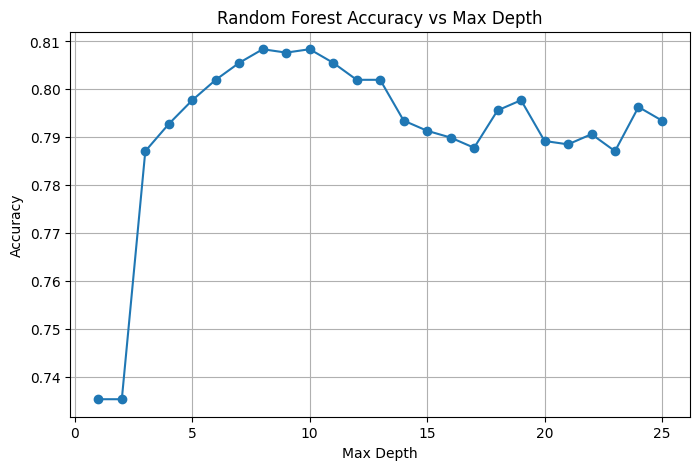

Best Depth: 8
Best Accuracy: 0.808374733853797


In [28]:
E3=model_evaluate(50,25)

Depth: 1, Accuracy: 0.7352732434350603
Depth: 2, Accuracy: 0.7352732434350603
Depth: 3, Accuracy: 0.7842441447835344
Depth: 4, Accuracy: 0.7899219304471257
Depth: 5, Accuracy: 0.801277501774308
Depth: 6, Accuracy: 0.7984386089425124
Depth: 7, Accuracy: 0.8048261178140526
Depth: 8, Accuracy: 0.8048261178140526
Depth: 9, Accuracy: 0.8076650106458482
Depth: 10, Accuracy: 0.8090844570617459
Depth: 11, Accuracy: 0.8069552874378992
Depth: 12, Accuracy: 0.794889992902768
Depth: 13, Accuracy: 0.8026969481902059
Depth: 14, Accuracy: 0.7963094393186657
Depth: 15, Accuracy: 0.7842441447835344
Depth: 16, Accuracy: 0.7885024840312278
Depth: 17, Accuracy: 0.7835344215755855
Depth: 18, Accuracy: 0.801277501774308
Depth: 19, Accuracy: 0.7927608232789212
Depth: 20, Accuracy: 0.7927608232789212
Depth: 21, Accuracy: 0.7885024840312278
Depth: 22, Accuracy: 0.7863733144073811
Depth: 23, Accuracy: 0.7863733144073811
Depth: 24, Accuracy: 0.7828246983676366
Depth: 25, Accuracy: 0.7849538679914834


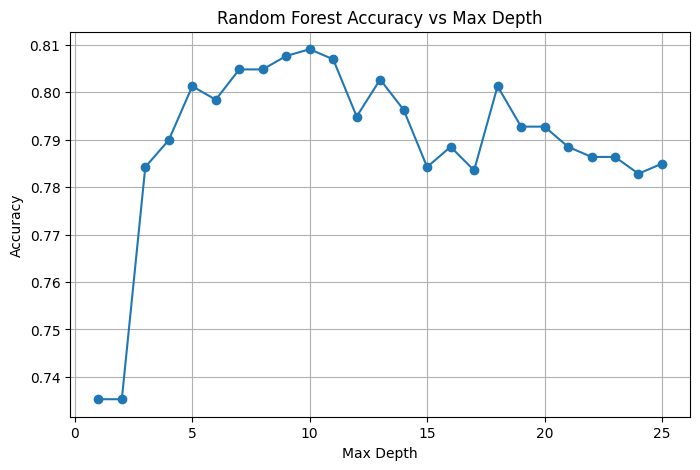

Best Depth: 10
Best Accuracy: 0.8090844570617459


In [29]:
E4=model_evaluate(30,25)

In [31]:
## Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    random_state=42
)

## Full pipeline
model =  Pipeline([
        ('cleaning',FunctionTransformer(basic_cleaning)),
        ('preprocessing',preprocessor),
        ('model', rf_model)])

# Train model
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
## Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("model accuracy:",accuracy)

model accuracy: 0.8090844570617459


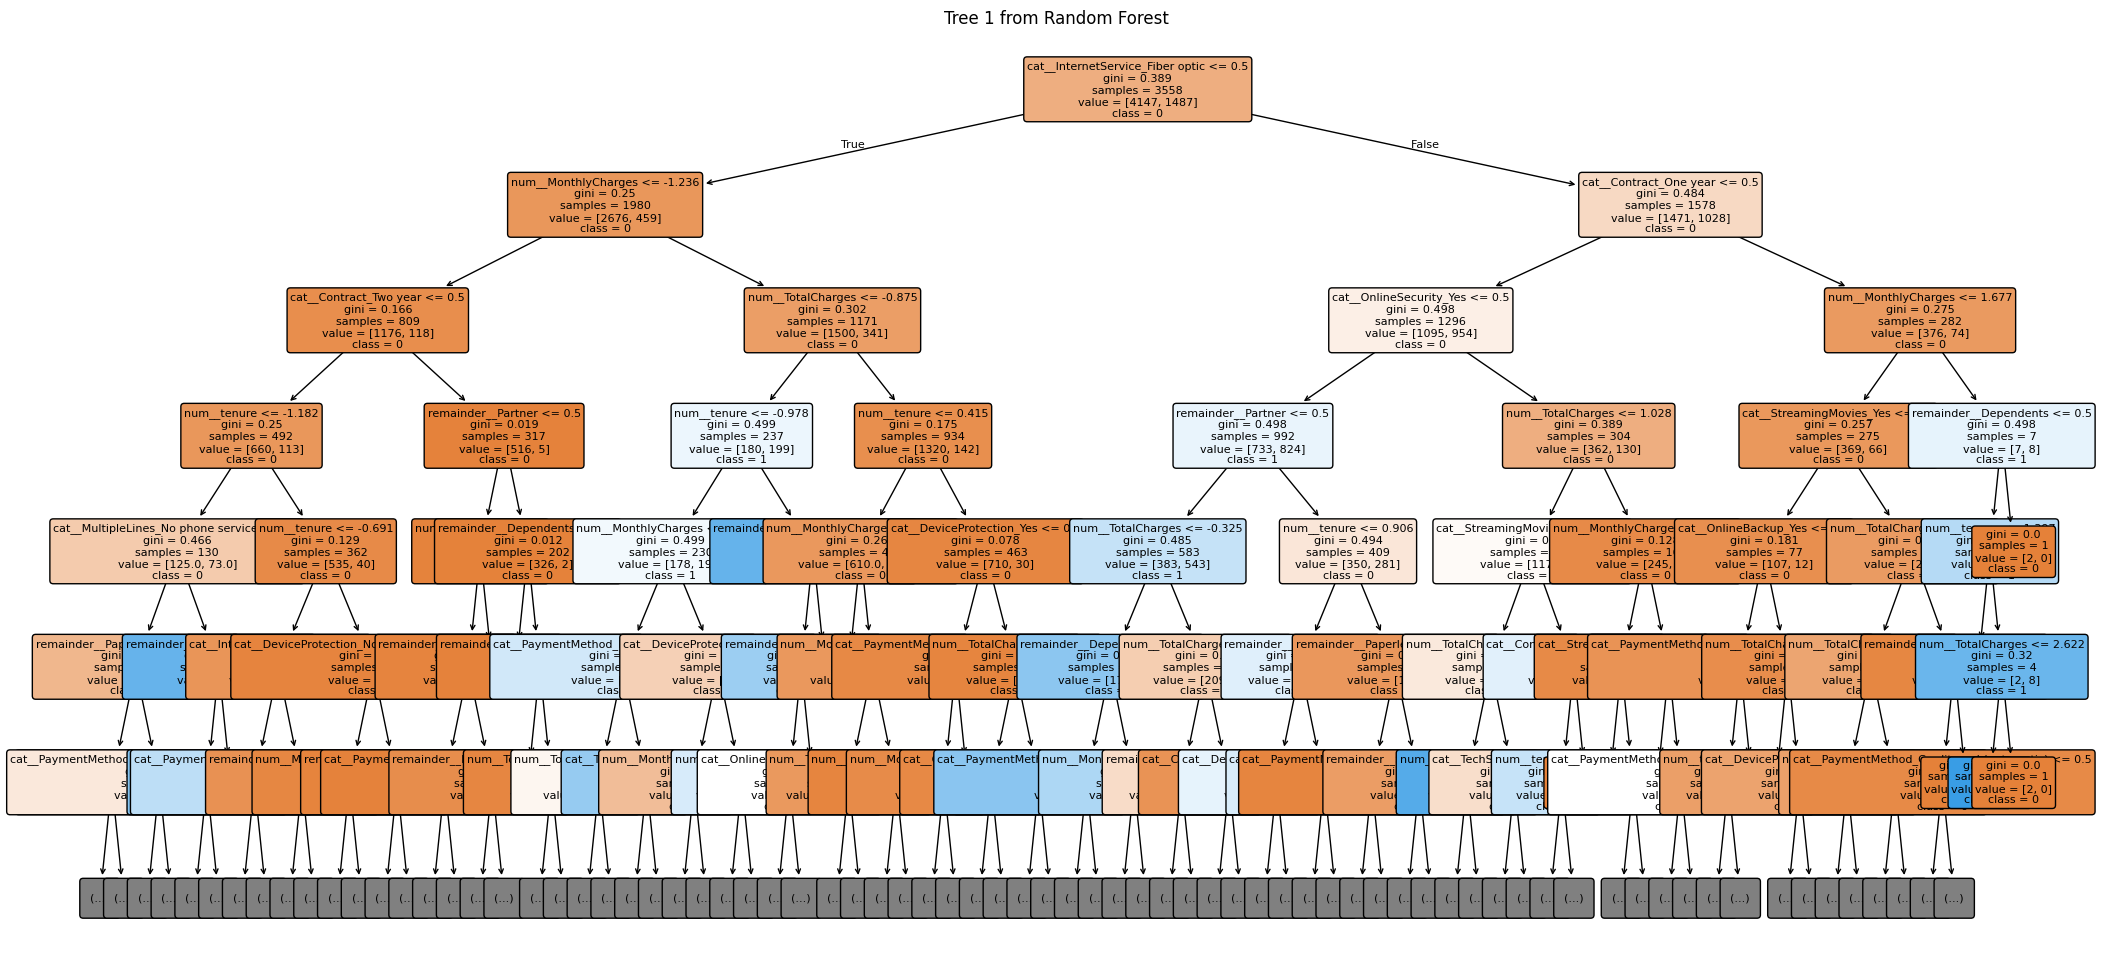

In [33]:
# ploting tree structure of base model
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extract trained Random Forest
rf = model.named_steps['model']

# Get transformed feature names
feature_names = model.named_steps[
    'preprocessing'
].get_feature_names_out()

# Number of trees to visualize
n_trees = 1

for i in range(n_trees):

    # Select tree
    tree = rf.estimators_[i]

    # Plot
    plt.figure(figsize=(25, 12))

    plot_tree(
        tree,
        filled=True,
        rounded=True,
        fontsize=8,
        feature_names=feature_names,
        class_names=[str(c) for c in rf.classes_],
        max_depth=6
    )

    plt.title(f"Tree {i+1} from Random Forest")

    plt.show()